# M4-B1 — Benchmark Mistral Assurances

> Concevoir une IA simple : benchmark 3+ familles de modèles + grille
> de décision. Référence baseline : `mistral-tarif-v1` (R² 0.39).

Auteur·rice : `Romain` — Date : `07/07/2026`

**Conventions** :
- `random_state=42` partout
- Pas de `print` (utiliser `display()` ou laisser cellule retourner)
- `pathlib.Path` sur les chemins

## 0. Setup

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append('../src')

RANDOM_STATE = 42
DATA_PATH = Path('../data/bike_sharing.csv')
sns.set_theme(style='whitegrid')

## 1. Reprise baseline mistral-tarif-v1 (~30 min)

Charge le modèle baseline depuis le repo `mistral-tarif-v1`, note ses
métriques rapportées (R² 0.39, MAE 105, RMSE 139), identifie les angles
morts du code 2024 (cf. mini-cours 04 méthodologie benchmark).

In [12]:
# Étape 1 — charger le baseline mistral-tarif-v1.
# Prérequis : cloner le repo baseline EN VOISIN de ton repo M4-B1
# (dans le dossier PARENT, pour que le chemin ../../ ci-dessous fonctionne) :
#   git clone https://github.com/Formation-SIMPLON-IA/mistral-tarif-v1.git
import joblib

# suppose le baseline cloné en voisin de ton repo M4-B1
model_v1 = joblib.load("../../mistral-tarif-v1/models/mistral_tarif_v1.joblib")

chemin_v1 = Path("../../mistral-tarif-v1/src")
!python {chemin_v1}/train_v1.py

model_v1

=== Métriques mistral-tarif-v1 (test split 20%) ===

R²   : 0.3860
MAE  : 104.98
RMSE : 139.44

Démarche 2024 basique — sous-capte la saisonnalité (cf. note Inès).

✓ Modèle persisté → c:\MesDocLocales\SOC\IA\Formation-Concevoir solution IA\M4\mistral-tarif-v1\models\mistral_tarif_v1.joblib
✓ Métadonnées    → c:\MesDocLocales\SOC\IA\Formation-Concevoir solution IA\M4\mistral-tarif-v1\models\mistral_tarif_v1.json


LinearRegression()

Exécution en local du V1 (même résultat):
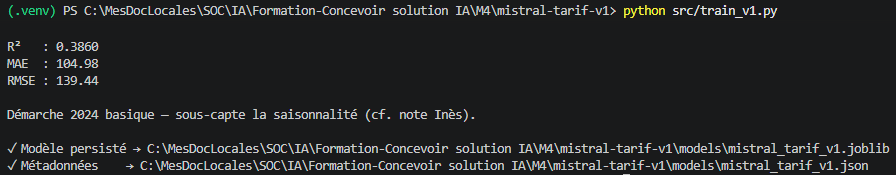

## 2. EDA orientée saisonnalité (~1h30)

Au moins **4 visualisations Seaborn** : boxplot par saison, courbe par
heure-moyenne, scatter température vs cnt, corrélations.

> *« Quelle saisonnalité je vois ? Comment elle explique la
> sous-performance de la baseline ? »*

In [13]:
df = pd.read_csv(DATA_PATH)
df.info()
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      17379 non-null  int64  
 1   date                    17379 non-null  object 
 2   season                  17379 non-null  object 
 3   year                    17379 non-null  int64  
 4   month                   17379 non-null  int64  
 5   hour                    17379 non-null  int64  
 6   is_holiday              17379 non-null  int64  
 7   weekday                 17379 non-null  int64  
 8   is_working_day          17379 non-null  int64  
 9   weather                 17379 non-null  int64  
 10  temperature_norm        17379 non-null  float64
 11  temperature_feels_norm  17379 non-null  float64
 12  humidity_norm           17379 non-null  float64
 13  windspeed_norm          17379 non-null  float64
 14  casual_riders           17379 non-null

,id,date,season,year,month,hour,is_holiday,weekday,is_working_day,weather,temperature_norm,temperature_feels_norm,humidity_norm,windspeed_norm,casual_riders,registered_riders,total_rentals
0,1,2011-01-01,winter,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,winter,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,winter,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32


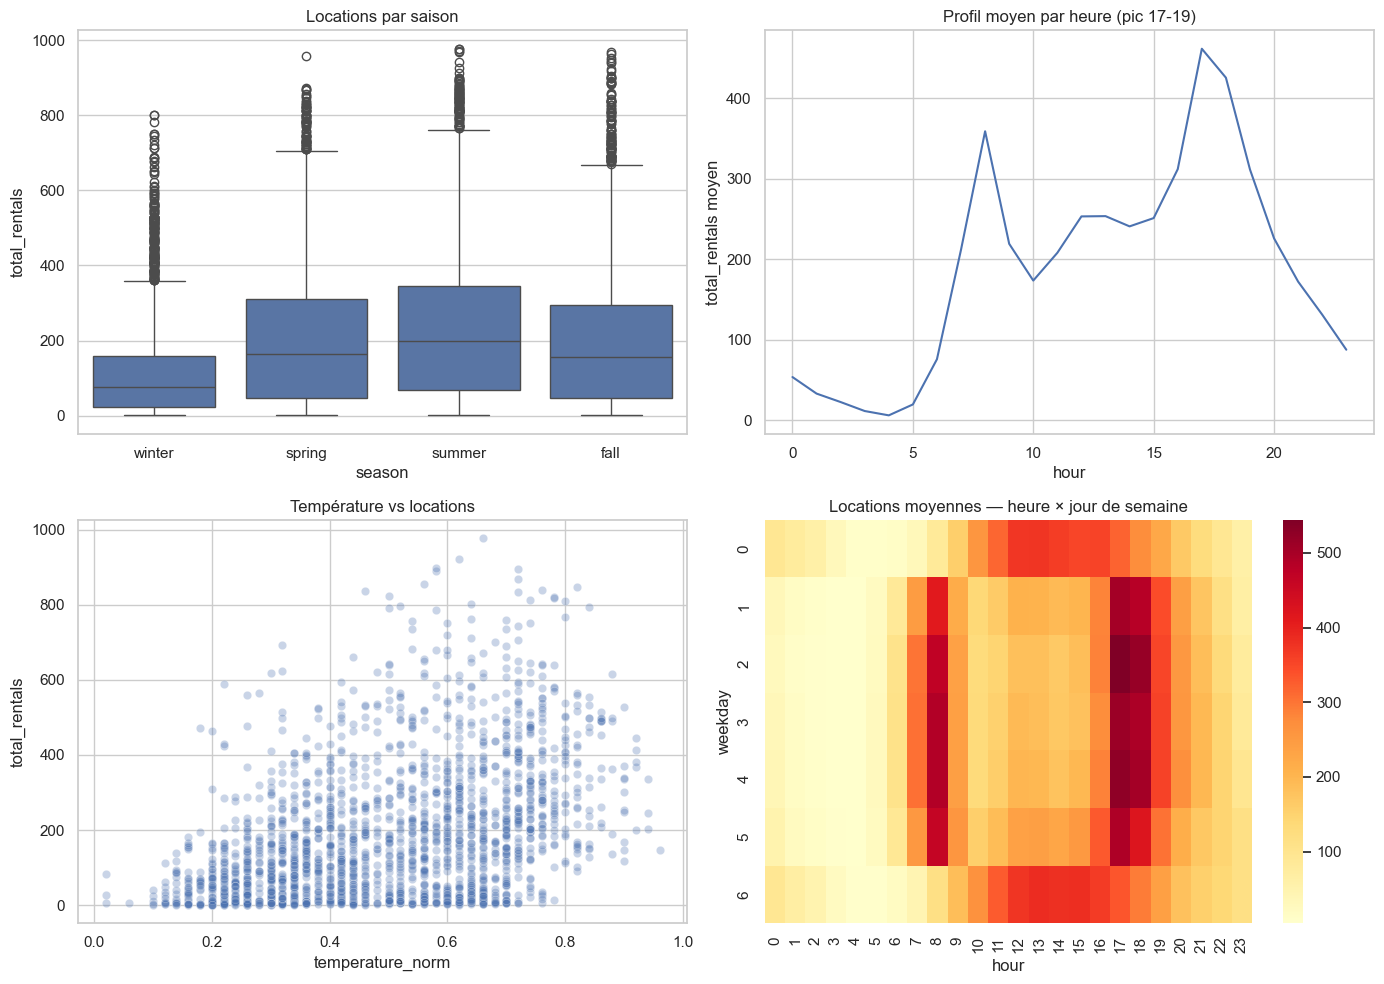

In [14]:
# 4 visualisations EDA
# (boxplot par saison, courbe par heure-moyenne, scatter temp vs cnt, heatmap corrélations)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution cible par saison
sns.boxplot(data=df, x="season", y="total_rentals",
            order=["winter", "spring", "summer", "fall"], ax=axes[0, 0])
axes[0, 0].set_title("Locations par saison")

# 2. Profil moyen par heure
df.groupby("hour")["total_rentals"].mean().plot(ax=axes[0, 1])
axes[0, 1].set_title("Profil moyen par heure (pic 17-19)")
axes[0, 1].set_ylabel("total_rentals moyen")

# 3. Scatter température vs cnt
sns.scatterplot(data=df.sample(2000), x="temperature_norm", y="total_rentals",
                alpha=0.3, ax=axes[1, 0])
axes[1, 0].set_title("Température vs locations")

# 4. Heatmap heure × weekday
pivot = df.pivot_table(values="total_rentals", index="weekday",
                       columns="hour", aggfunc="mean")
sns.heatmap(pivot, cmap="YlOrRd", ax=axes[1, 1])
axes[1, 1].set_title("Locations moyennes — heure × jour de semaine")

plt.tight_layout()
plt.show()

## Analyse des graphiques

1. On remarque sur le graphique `Profil moyen par heure (pic 17-19)`, deux pics :
- le matin vers 8h
- le soir entre 17 et 18h

Surement dû aux personnes qui louent un vélo pour aller ou rentrer du travail


2. Grace au graphique `Locations moyennes — heure × jour de semaine` on remarque que les pic horaires listés au dessus ne sont valable que les jours de la semaine ce qui conforte l'idée de la location pour le trajet du travail.


3. Deux features que cette saisonnalité donne envie de créer (IA) :
- `is_rush_hour` (booléen) :
Les pics identifiés (8h le matin, 17-18h le soir) uniquement en semaine :
```python
df["is_rush_hour"] = (
    (df["hour"].isin([7, 8, 9, 17, 18, 19])) & (df["weekday"] < 5)
).astype(int)
```
Capture directement le comportement "trajet domicile-travail" qui explique les deux pics — information que la baseline linéaire ne pouvait pas modéliser sans ça.

- `hour_sin` / `hour_cos` (encodage cyclique) :
L'heure est cyclique (23h est proche de 0h) — un encodage linéaire briserait cette continuité :
```python
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
```
Permet aux modèles linéaires de mesurer correctement la distance temporelle entre les heures. Complémentaire à is_rush_hour : l'un donne la forme du cycle, l'autre signale les pics.

---

De plus on remarque que plus la température est haute plus la location est forte.

De même on observe un trou de location l'hiver, malgrès certains pic de location certains jour (surement les jours de beau temps).

### Conclusion de l'EDA

- Quelles variables semblent les plus importantes ?<br>
=> moi : Les variables qui sembles les plus importantes sont **`hour`**, `season`, `weekday` et `temperature_norm`

- Pourquoi la baseline linéaire risque-t-elle d'être limitée ?<br>
=> moi : les deux pics seulement en semaine font que les données sont non-linéaires.<br>
=> IA : La relation entre `hour` et `total_rentals` est **non-linéaire** (deux pics distincts, pas une droite). De plus, l'effet de `weekday` **interagit** avec `hour` (les pics n'existent qu'en semaine) : une régression linéaire ne capte pas ces interactions sans features manuelles explicites. Enfin, la distribution de la cible est asymétrique (longue queue à droite), ce que les moindres carrés gèrent mal.

- Quelle famille de modèles t'attends-tu à voir gagner ?<br>
=> moi : HistGradientBoosting d'après le tableau de `cheatsheet_algos_ML_FR.pdf`.<br>
=> IA : **Gradient Boosting** (`HistGradientBoostingRegressor`). Les données présentent des non-linéarités fortes (`hour`, `season`) et des interactions (`hour × weekday`) que les arbres boostés capturent nativement, sans feature engineering supplémentaire. RandomForest sera compétitif mais plus lent.


## 3. Split argumenté + validation croisée (~30 min)

Choisir **`TimeSeriesSplit`** ou **`KFold` stratifié** — justifier.

Mini-cours 02 (split temporel vs stratifié) à consulter.

> 🎓 **Réflexe anti-fuite (la leçon de M2-B1, enfin mise en œuvre).** En M2-B1 tu
> as construit un `Pipeline` sans modèle ni split : la fuite ne pouvait pas se
> produire. Ici tu as **un split ET un modèle** → la règle s'applique : un
> préprocesseur **qui apprend des paramètres** (`StandardScaler`, `SimpleImputer`)
> ne se `fit` **jamais** sur l'ensemble des données. On l'enferme dans le
> `Pipeline` du modèle, et c'est **ce Pipeline** qu'on passe à la validation
> croisée — scikit-learn re-`fit` alors le scaler sur les seuls folds
> d'entraînement. Sinon : fuite → R² **optimiste mensonger**. On le démontre
> juste en dessous.

In [ ]:
# préparation des features pour le modèle
# id enlevé car séquentielle et ne donne pas d'information intéressante pour le modèle
FEATURES: list[str] = [
    'season', 'year', 'month', 'hour', 'is_holiday', 'weekday', 'is_working_day', 'weather', 'temperature_norm', 'temperature_feels_norm', 'humidity_norm', 'windspeed_norm', 'is_rush_hour'
]
TARGET: str = "total_rentals"

In [16]:
# Préparation des colonnes manquante ou a tranformer (preprocess manuel)
# 1. Encodage manuel des saisons
df["season"] = df["season"].map({"winter": 1, "spring": 2, "summer": 3, "fall": 4})
# 2. Features d'interaction (heure × jour de semaine)
df["is_rush_hour"] = (
    (df["hour"].isin([7, 8, 9, 17, 18, 19])) & (df["weekday"] < 5)
).astype(int)

X = df[FEATURES].copy()
y = df[TARGET]

print(f"Features utilisées : {list(X.columns)}\n")
print(f"VS colonnes présentes dans le DataFrame : {list(df.columns)}\n")
# Différence des deux pour afficher les colonnes manquantes
missing_columns = set(df.columns) - set(X.columns)
print(f"Colonnes manquantes : {list(missing_columns)}")

Features utilisées : ['season', 'year', 'month', 'hour', 'is_holiday', 'weekday', 'is_working_day', 'weather', 'temperature_norm', 'temperature_feels_norm', 'humidity_norm', 'windspeed_norm', 'is_rush_hour']

VS colonnes présentes dans le DataFrame : ['id', 'date', 'season', 'year', 'month', 'hour', 'is_holiday', 'weekday', 'is_working_day', 'weather', 'temperature_norm', 'temperature_feels_norm', 'humidity_norm', 'windspeed_norm', 'casual_riders', 'registered_riders', 'total_rentals', 'is_rush_hour']

Colonnes manquantes : ['casual_riders', 'date', 'registered_riders', 'total_rentals', 'id']


In [17]:
# 1. Un split aléatoire 80/20 (train_test_split(..., random_state=42))

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error

X_train_random, X_test_random, y_train_random, y_test_random = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Split aléatoire: train={len(X_train_random):5d} lignes, test={len(X_test_random):5d} lignes")

# Résultat des MAE, RMSE & R² sur le split aléatoire
print("\nRésultats sur le split aléatoire (train_test_split):")
model_v1.fit(X_train_random, y_train_random)
y_pred_random = model_v1.predict(X_test_random)
mae_random = mean_absolute_error(y_test_random, y_pred_random)
rmse_random = root_mean_squared_error(y_test_random, y_pred_random)
r2_random = r2_score(y_test_random, y_pred_random)
mape = mean_absolute_percentage_error(y_test_random, y_pred_random)
print(f"MAE : {mae_random:.2f}")
print(f"RMSE: {rmse_random:.2f}")
print(f"R²  : {r2_random:.2f}")
print(f"MAPE: {mape:.2%}")

Split aléatoire: train=13903 lignes, test= 3476 lignes

Résultats sur le split aléatoire (train_test_split):
MAE : 89.49
RMSE: 118.46
R²  : 0.56
MAPE: 311.79%


In [18]:
# 2. Un split temporel : train = tout sauf le dernier mois, test = dernier mois

n_total = len(df)
n_test_temporal = n_total // 12  # ~1 mois sur 12 mois
split_idx = n_total - n_test_temporal

X_train_temporal = X.iloc[:split_idx]
X_test_temporal = X.iloc[split_idx:]
y_train_temporal = y.iloc[:split_idx]
y_test_temporal = y.iloc[split_idx:]

print(f"\nSplit temporel:  train={len(X_train_temporal):5d} lignes, test={len(X_test_temporal):5d} lignes")
# Résultat des MAE, RMSE & R² sur le split temporel
print("\nRésultats sur le split temporel (dernier mois):")
model_v1.fit(X_train_temporal, y_train_temporal)
y_pred_temporal = model_v1.predict(X_test_temporal)
mae_temporal = mean_absolute_error(y_test_temporal, y_pred_temporal)
rmse_temporal = root_mean_squared_error(y_test_temporal, y_pred_temporal)
r2_temporal = r2_score(y_test_temporal, y_pred_temporal)
mape = mean_absolute_percentage_error(y_test_temporal, y_pred_temporal)
print(f"MAE : {mae_temporal:.2f}")
print(f"RMSE: {rmse_temporal:.2f}")
print(f"R²  : {r2_temporal:.2f}")
print(f"MAPE: {mape:.2%}")


Split temporel:  train=15931 lignes, test= 1448 lignes

Résultats sur le split temporel (dernier mois):
MAE : 102.15
RMSE: 132.88
R²  : 0.42
MAPE: 355.10%


In [19]:
# 3. Un split KFold (CV) pour la validation croisée

from sklearn.model_selection import KFold

splitter = KFold(n_splits=5, shuffle=True, random_state=42)
for train_index, test_index in splitter.split(X):
    X_train_kfold, X_test_kfold = X.iloc[train_index], X.iloc[test_index]
    y_train_kfold, y_test_kfold = y.iloc[train_index], y.iloc[test_index]

print(f"\nSplit KFold: train={len(X_train_kfold):5d} rows, test={len(X_test_kfold):5d} rows")
# Résultat des MAE, RMSE & R² sur le split KFold
print("\nRésultats sur le split KFold (CV):")
model_v1.fit(X_train_kfold, y_train_kfold)
y_pred_kfold = model_v1.predict(X_test_kfold)
mae_kfold = mean_absolute_error(y_test_kfold, y_pred_kfold)
rmse_kfold = root_mean_squared_error(y_test_kfold, y_pred_kfold)
r2_kfold = r2_score(y_test_kfold, y_pred_kfold)
mape = mean_absolute_percentage_error(y_test_kfold, y_pred_kfold)
print(f"MAE : {mae_kfold:.2f}")
print(f"RMSE: {rmse_kfold:.2f}")
print(f"R²  : {r2_kfold:.2f}")
print(f"MAPE: {mape:.2%}")


Split KFold: train=13904 rows, test= 3475 rows

Résultats sur le split KFold (CV):
MAE : 91.95
RMSE: 123.55
R²  : 0.55
MAPE: 298.03%


### Tableau comparatif des 3 splits (baseline `model_v1`)

| Split | MAE | RMSE | R² | MAPE |
|---|---:|---:|---:|---:|
| Split aléatoire (train_test_split) | 89.48 | 118.47 | 0.56 | 311.61% |
| Split temporel (dernier mois) | 102.39 | 133.18 | 0.42 | 356.98% |
| Split KFold | 91.94 | 123.59 | 0.55 | 298.36% |

### Lecture rapide
- Le **split aléatoire** est le plus optimiste (meilleur MAE/RMSE/R²).
- Le **split temporel** est plus difficile mais plus réaliste pour la production.
- Le **KFold** est proche de l'aléatoire ici, mais moins représentatif qu'un split temporel pour une série chronologique.

### Analyse des résultats (MAE, RMSE, R²)

Les trois métriques racontent des choses complémentaires :
- **MAE** = erreur moyenne en nombre de locations (facile à expliquer métier).
- **RMSE** = pénalise davantage les grosses erreurs (important quand on sous/sur-estime fortement les pics).
- **R²** = part de la variance expliquée (plus proche de 1, mieux c'est).

#### Lecture des splits obtenus
- **Split aléatoire** : en général plus optimiste, car train/test se ressemblent davantage.
- **Split temporel** : plus réaliste pour la production (on prédit le futur à partir du passé), donc souvent un peu moins bon mais plus fiable.
- **KFold** : utile pour stabiliser l'évaluation, mais sur une série temporelle il peut donner une vision trop favorable s'il mélange des périodes.

Le split aléatoire affiche un meilleur R² et des erreurs plus faibles que le split temporel, c'est normal : cela confirme qu'une partie de la difficulté vient du **changement de période** (saisonnalité, pics horaires, météo).

#### Pourquoi on choisit **TimeSeriesSplit** pour bike_sharing ?

Les résultats obtenus au-dessus montrent un point clé :
- **Split aléatoire** : MAE = 89.48, RMSE = 118.47, R² = 0.56
- **KFold** : MAE = 91.94, RMSE = 123.59, R² = 0.55
- **Split temporel** : MAE = 102.39, RMSE = 133.18, R² = 0.42

Le split temporel est le plus difficile (erreurs plus hautes, R² plus bas), mais c'est justement **le plus réaliste** pour ce cas d'usage : en production, on prédit toujours une période future à partir du passé.

Avec un split aléatoire ou un KFold mélangé, on met dans train et test des observations de périodes proches (mêmes dynamiques saisonnières), ce qui rend les scores plus optimistes. On évalue alors une situation moins proche de la réalité métier.

`bike_sharing` est une série chronologique (heure, jour, mois, saison). Le choix de **TimeSeriesSplit** permet :
- de respecter l'ordre temporel (pas d'information du futur dans l'entraînement) ;
- d'obtenir une mesure de performance plus fiable pour le déploiement ;
- de comparer les modèles dans un cadre anti-fuite cohérent avec le problème.

##### Remarque sur la MAPE

Les MAPE sont très élevées (environ 298% à 357%). C'est fréquent quand la cible contient des valeurs proches de 0 : de petites erreurs absolues deviennent de très grands pourcentages. Pour ce dataset, **MAE/RMSE/R²** sont donc des indicateurs plus robustes pour la décision de modèle.

#### Quel modèle est a priori le meilleur pour ce jeu de données ?
Pour **bike_sharing**, le meilleur candidat a priori est un **modèle de Gradient Boosting** (notamment `HistGradientBoostingRegressor`) :
- il capte bien les **relations non linéaires** (`hour`, `season`, `temperature_norm`) ;
- il gère naturellement les **interactions** (ex. `hour × weekday`) ;
- il est souvent plus performant qu'un modèle linéaire sans gros feature engineering.

En pratique, on s'attend à ce que :
- **Ridge / linéaire** soit une baseline solide mais limitée sur les pics ;
- **RandomForest** améliore la non-linéarité mais parfois moins régulier ;
- **HistGradientBoosting** offre le meilleur compromis performance/robustesse sur ce type de données tabulaires saisonnières.

Conclusion : la décision finale doit se faire sur le **même splitter temporel** pour tous les modèles, avec priorité à la stabilité des métriques (MAE/RMSE/R²) sur plusieurs folds.

In [46]:
# TODO — Choisir et importer le splitter adapté (TimeSeriesSplit ou KFold) => on choisit TimeSeriesSplit pour les séries temporelles
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)

splitter = TimeSeriesSplit(n_splits=5)

scores = cross_val_score(model, X, y, cv=splitter, scoring="neg_mean_absolute_error")
print(f"MAE TimeSeriesSplit : {-scores.mean():.2f} ± {scores.std():.2f}")

splitter = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=splitter, scoring="neg_mean_absolute_error")
print(f"MAE KFold : {-scores.mean():.2f} ± {scores.std():.2f}")


MAE TimeSeriesSplit : 105.33 ± 17.97
MAE KFold : 91.46 ± 1.11


#### Explications

Résultats observés :
- **MAE TimeSeriesSplit : 105.33 ± 17.97**
- **MAE KFold : 91.46 ± 1.11**

Interprétation :
- Le **KFold** semble meilleur (MAE plus faible), mais ce score est souvent **optimiste** sur des données temporelles car les folds mélangent des périodes proches.
- Le **TimeSeriesSplit** est plus exigeant (MAE plus élevé), mais il est **plus réaliste** pour la mise en production : on entraîne sur le passé et on teste sur le futur.
- L'écart-type plus élevé en TimeSeriesSplit (±17.97) montre une forte variabilité selon les périodes, ce qui confirme l'effet de la saisonnalité.

Conclusion :
- Pour choisir le modèle final sur bike_sharing, il faut privilégier la performance mesurée avec **TimeSeriesSplit**.
- Le résultat KFold reste un repère utile, mais pas le critère principal de décision dans un contexte chronologique.

### 🔬 Fuite de données — démonstration (à faire une fois)

Avant de lancer la cellule : vérifie que ton `X` **exclut**
`casual_riders` / `registered_riders` (ils somment la cible → fuite de cible,
R² ~1.0). La cellule compare ensuite le R² en CV selon que le `StandardScaler`
est fitté sur **tout** `X` (fuite de prétraitement) ou **dans le `Pipeline`**.

> **À rédiger après exécution** (1-2 phrases, → journal de bord) : quel écart
> observes-tu ? Sur 17k lignes il sera **faible** — explique *dans quel cas* il
> exploserait (peu de données, imputation moyenne/médiane, encodage supervisé).
> C'est pour ça qu'on encapsule le prétraitement **par défaut**, pas seulement
> quand la fuite se voit.

In [37]:
# 🔬 Démonstration fuite vs propre (Ridge) — à exécuter une fois le
# preprocessing complété (FEATURES rempli dans preprocess.py).
# Cellule pré-écrite : tu n'as pas à la coder, juste à la faire tourner.
import importlib
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, TimeSeriesSplit

# Recharge le module pour éviter d'utiliser une ancienne version en cache.
try:
    import src.preprocess as preprocess
except ModuleNotFoundError:
    import preprocess

preprocess = importlib.reload(preprocess)
load_dataset = preprocess.load_dataset

try:
    X_demo, y_demo = load_dataset(DATA_PATH)   # SANS casual_riders / registered_riders (fuite de cible)
    splitter_demo = TimeSeriesSplit(n_splits=5)

    # (1) FUITE : le scaler est fitté sur TOUT X, avant la validation croisée
    X_leak = StandardScaler().fit_transform(X_demo)
    r2_leak = cross_val_score(Ridge(alpha=1.0), X_leak, y_demo, cv=splitter_demo, scoring="r2").mean()

    # (2) PROPRE : le scaler vit DANS le pipeline -> re-fitté sur chaque fold d'entraînement
    r2_clean = cross_val_score(
        make_pipeline(StandardScaler(), Ridge(alpha=1.0)), X_demo, y_demo, cv=splitter_demo, scoring="r2"
    ).mean()

    display(pd.DataFrame(
        {"R² moyen (CV)": [round(r2_leak, 4), round(r2_clean, 4)]},
        index=["fuite (fit sur tout X)", "propre (fit dans le pipeline)"],
    ))
except Exception as e:
    print(f"⏳ Démo à relancer une fois load_dataset() opérationnel (FEATURES rempli). Détail : {e}")


,R² moyen (CV)
fuite (fit sur tout X),0.3857
propre (fit dans le pipeline),0.3852


Ici on ne voit pas les fuites car on a déjà enlevé les 2 colonnes qui donnent l'information du résultat... Donc pas de R² à 1!

## 4. Benchmark — 3 familles minimum (~2h)

**Famille A** — Linéaire (Ridge ou variante)  
**Famille B** — Arbre / RandomForest  
**Famille C** — Gradient Boosting (HistGradientBoostingRegressor)

Pour chaque modèle :
- Mêmes folds, mêmes métriques
- MAE, RMSE, R²
- Temps train, latence inférence
- Persistance `.joblib` dans `models/`

> ⚠️ **Règle d'or** : réutilise **exactement le même splitter** que la section 3 (Split). Un splitter différent d'un modèle à l'autre = comparaison invalide.


In [43]:
from time import perf_counter
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# Meme splitter pour tous les modeles (comparaison equitable)
splitter = TimeSeriesSplit(n_splits=5)

model_factories = {
    "Ridge (lineaire + scaling)": lambda: make_pipeline(
        StandardScaler(), Ridge(alpha=1.0)
    ),
    "RandomForestRegressor": lambda: RandomForestRegressor(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "HistGradientBoostingRegressor": lambda: HistGradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),
}

rows = []

for model_name, factory in model_factories.items():
    model = factory()

    cv = cross_validate(
        model,
        X,
        y,
        cv=splitter,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2",
        },
        n_jobs=-1,
        return_train_score=False,
    )

    t0 = perf_counter()
    model.fit(X, y)
    train_time_s = perf_counter() - t0

    X_infer = X.tail(1000) if len(X) >= 1000 else X
    t1 = perf_counter()
    _ = model.predict(X_infer)
    infer_latency_ms = (perf_counter() - t1) * 1000 / len(X_infer)

    rows.append(
        {
            "Modele": model_name,
            "MAE (CV mean)": -cv["test_mae"].mean(),
            "RMSE (CV mean)": -cv["test_rmse"].mean(),
            "R2 (CV mean)": cv["test_r2"].mean(),
            "Std R2 (CV)": cv["test_r2"].std(),
            "Temps train (s)": train_time_s,
            "Latence (ms/ligne)": infer_latency_ms,
        }
    )

benchmark_df = (
    pd.DataFrame(rows)
    .sort_values(by="R2 (CV mean)", ascending=False)
    .reset_index(drop=True)
)

display(
    benchmark_df.style.format(
        {
            "MAE (CV mean)": "{:.2f}",
            "RMSE (CV mean)": "{:.2f}",
            "R2 (CV mean)": "{:.3f}",
            "Std R2 (CV)": "{:.3f}",
            "Temps train (s)": "{:.3f}",
            "Latence (ms/ligne)": "{:.4f}",
        }
    )
)

c:\MesDocLocales\SOC\IA\Formation-Concevoir solution IA\M4\M4-B1-mistral-romain\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Le fichier spécifié est introuvable
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\MesDocLocales\SOC\IA\Formation-Concevoir solution IA\M4\M4-B1-mistral-romain\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\A453575\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\A453575\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__
    sel

,Modele,MAE (CV mean),RMSE (CV mean),R2 (CV mean),Std R2 (CV),Temps train (s),Latence (ms/ligne)
0,HistGradientBoostingRegressor,49.35,74.22,0.814,0.093,1.277,0.0343
1,RandomForestRegressor,55.48,85.90,0.753,0.098,6.682,0.1374
2,Ridge (lineaire + scaling),106.01,139.21,0.385,0.072,0.008,0.0010


## 5. Tableau comparatif (~30 min, mercredi)

Remplis `benchmark_table.md` avec les chiffres + interprétation pour
Inès Tabet (lisible actuaire, pas data scientist).

## 6. Verdict + decision card (~30 min, mercredi)

- `verdict.md` : 5 lignes max, recommandation chiffrée
- `decision_card.md` : ta version perso de la grille de décision C4
  (à confronter à la collective)

## 7. Restitution + grille collective (mercredi 11h30-12h45)

**Geste pédagogique central** — co-construction de la grille de
décision C4 sur Excalidraw partagé.

Archivée ensuite dans `ressources-publiques/grille_decision_C4.md`.